In [4]:
import ast
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from datasets import load_dataset

dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x)else x)

c:\Users\heroj\anaconda3\envs\proyecto_python1\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
df_DA = df[df['job_title_short']== 'Data Analyst'].copy()


In [6]:
df_DA['job_posted_month_no'] = df_DA['job_posted_date'].dt.month

df_DA_explode = df_DA.explode('job_skills')

df_DA_pivot = df_DA_explode.pivot_table(index='job_posted_month_no', columns='job_skills', aggfunc='size', fill_value=0)


In [7]:
df_DA_pivot.loc['Total'] = df_DA_pivot.sum()

df_DA_pivot = df_DA_pivot[df_DA_pivot.loc['Total'].sort_values(ascending=False).index]

df_DA_pivot = df_DA_pivot.drop('Total')

In [8]:
df_DA_pivot = df_DA_pivot.reset_index()
df_DA_pivot['job_posted_month'] = df_DA_pivot['job_posted_month_no'].apply(lambda x: pd.to_datetime(x, format='%m').strftime('%B'))
df_DA_pivot = df_DA_pivot.set_index('job_posted_month')
df_DA_pivot = df_DA_pivot.drop(columns='job_posted_month_no')




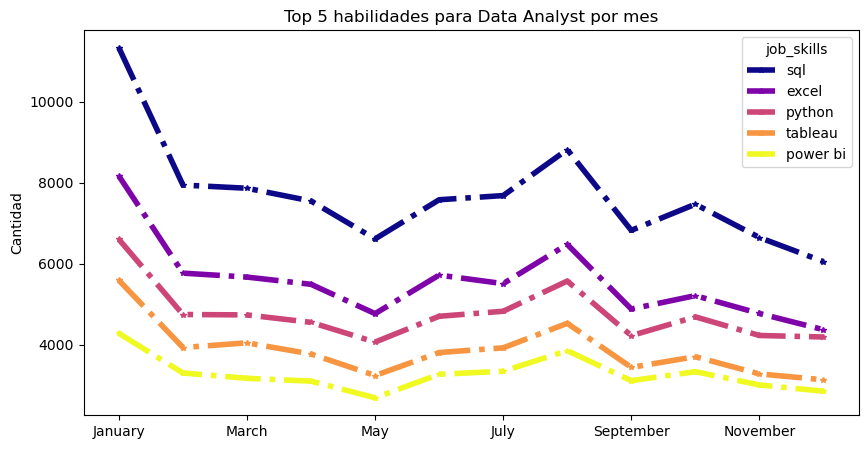

In [9]:
df_DA_pivot.iloc[:, :5].plot(
    kind='line',
    linewidth= 4,
    linestyle='-.',
    colormap='plasma',
    marker='*',
    markersize=4,
    figsize=(10,5)
    )

plt.title('Top 5 habilidades para Data Analyst por mes')
plt.ylabel('Cantidad')
plt.xlabel('')
plt.show()

In [13]:
df_exploded = df.explode('job_skills')
skill_stats = df_exploded.groupby('job_skills').agg(
    skill_count=('job_skills','count'),
    median_salary=('salary_year_avg', 'median') 
)

skill_count = 15
skill_stats = skill_stats.sort_values(by='skill_count', ascending=False).head(skill_count)

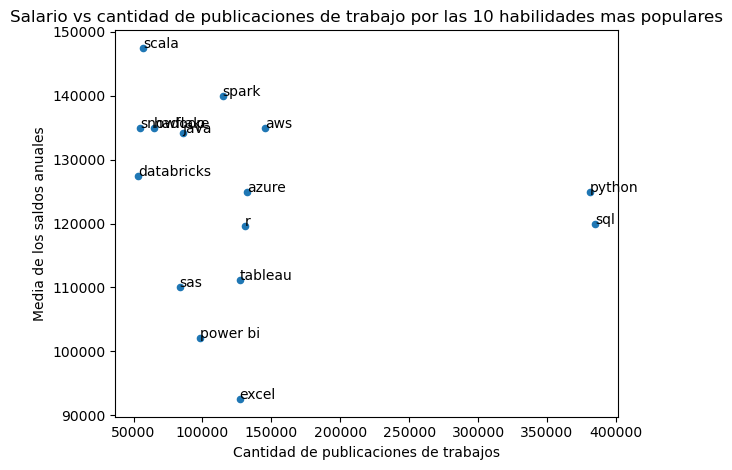

In [21]:
skill_stats.plot(kind='scatter', x='skill_count', y='median_salary')
plt.xlabel('Cantidad de publicaciones de trabajos')
plt.ylabel('Media de los saldos anuales')
plt.title('Salario vs cantidad de publicaciones de trabajo por las 10 habilidades mas populares')
plt.tight_layout()
for i, txt in enumerate(skill_stats.index):
    plt.text(skill_stats['skill_count'].iloc[i], skill_stats['median_salary'].iloc[i], txt)
plt.show()

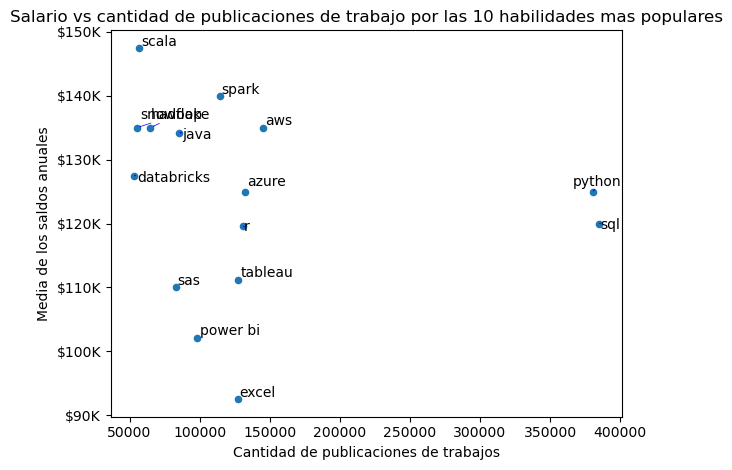

In [27]:
from adjustText import adjust_text


skill_stats.plot(kind='scatter', x='skill_count', y='median_salary')
texts = []

for i, txt in enumerate(skill_stats.index):
    texts.append(plt.text(skill_stats['skill_count'].iloc[i], skill_stats['median_salary'].iloc[i], txt))

adjust_text(texts, arrowprops=dict(arrowstyle="->", color='blue', lw=0.5))
ax = plt.gca()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y , pos: f'${int(y/1000)}K'))
plt.xlabel('Cantidad de publicaciones de trabajos')
plt.ylabel('Media de los saldos anuales')
plt.title('Salario vs cantidad de publicaciones de trabajo por las 10 habilidades mas populares')
plt.tight_layout()
plt.show()
